# Global Equity Momentum Strategy Analysis

Hello everyone. I created this small research to finally answer my question: Is Global Equity Momentum (GEM) a valid strategy worth applying in real life?

## Global Equity Momentum

Global Equity Momentum (GEM) is a rules-based investment strategy formalized by Gary Antonacci in 2012. The strategy combines the equity risk premium with two known style premia: trend and momentum, to rotate between U.S. and foreign stocks while moving to bonds when U.S. stocks exhibit a negative trend.

GEM uses both relative momentum (comparing strength across different assets) and absolute momentum (looking for positive past returns exceeding Treasury bill returns). The original strategy applies a 12-month lookback period to evaluate performance and rebalances positions monthly. It typically rotates between three asset classes: the S&P 500 index, MSCI All Country World ex-US index, and Barclays Capital US Aggregate Bond index.

## In This Research

This simulation analyzes and compares the following strategies:

- Simplest Buy and Hold - A baseline passive investment approach
- GEM (Original) - Standard GEM using only the original three instruments — BIL, SPY and VEU, with monthly rebalancing and a 12-month lookback
- GEM (Expanded Tickers): GEM using instruments: BIL, SPY, VEU, EEM, IAU, QQQ, TLT, and VGK, testing broader momentum signals.
- GEM with 90-Day Rebalancing Period - Modified GEM reducing transaction frequency to quarterly rebalancing for both original and expanded ticker universes
- GEM with 3-Year Comparison Time Window - Alternative GEM using a 36-month lookback period instead of the traditional 12 months as well for original and expanded ticker universes

## Data

I compiled a CSV dataset containing daily close prices for eight instruments:

- **BIL** - 1-3 Month T-Bill ETF
- **SPY** - S&P 500 ETF
- **VEU** - FTSE All-World ex-US ETF

---

- **EEM** - MSCI Emerging Markets ETF
- **IAU** - Gold Trust
- **QQQ** - Nasdaq-100 ETF
- **TLT** - 20+ Year Treasury Bond ETF
- **VGK** - FTSE Europe ETF

The simulation starts on 2005-03-10, when all data are available (there is no zero value).

### Data source 

- https://www.kaggle.com/datasets/benjaminpo/s-and-p-500-with-dividends-and-splits-daily-updated/data
- https://www.kaggle.com/datasets/jacksoncrow/stock-market-dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Global dark mode for all matplotlib plots in this notebook
plt.style.use("dark_background")
plt.rcParams.update(
    {
        "figure.facecolor": "#121212",
        "axes.facecolor": "#121212",
        "axes.edgecolor": "#bbbbbb",
        "axes.labelcolor": "#f0f0f0",
        "xtick.color": "#d9d9d9",
        "ytick.color": "#d9d9d9",
        "grid.color": "#666666",
        "text.color": "#f0f0f0",
    }
)

## Reading data

In [2]:
df = pd.read_csv("data/gem.csv")
print(df.head())

         Date     SPY     EEM    VEU    BIL     IAU    TLT    QQQ    VGK
0  2007-05-30  153.48  42.200  56.33  91.60  12.958  86.54  47.19  76.35
1  2007-05-31  153.32  42.320  56.62  91.60  13.118  86.38  47.41  76.60
2  2007-06-01  154.08  43.377  57.17  91.62  13.312  85.59  47.44  77.02
3  2007-06-04  154.10  43.183  57.28  91.64  13.310  85.98  47.58  77.51
4  2007-06-05  153.49  43.033  56.94  91.64  13.278  85.44  47.58  76.76


## Variables

The simulation is designed to evaluate the performance of different Global Equity Momentum (GEM) strategy variants based on configurable parameters:

- **REBALANCE_PERIOD**: Defines how often the portfolio is rebalanced to reflect current momentum signals (e.g., 90 days for quarterly rebalancing or monthly for standard GEM) (in days).
- **COMPARISON_TIME_WINDOW**: Sets the lookback period over which momentum is calculated, such as 12 months for classic GEM or 3 years in the extended variant (in days).
- **STARTING_CASH**: Specifies the initial capital available for investment in the simulation.

Both REBALANCE_PERIOD and COMPARISON_TIME_WINDOW are adjusted in the algorithm to account for the stock market being closed on Saturdays and Sundays (113 days in a year on average). This ensures that rebalancing and momentum calculations happen on valid trading days only, avoiding weekends and holidays.

## Configuration

In [3]:
TRANSACTION_COST = 0.05  # in %
ORIGINAL_TICKERS = ["BIL", "VEU", "SPY"]
EXTENDED_TICKERS = ["BIL", "VEU", "SPY", "EEM", "IAU", "QQQ", "TLT", "VGK"]
TRADING_DAYS_IN_YEAR = 252
STARTING_CASH = 1000
REBALANCE_PERIOD = 30  # in days
COMPARISON_TIME_WINDOW = 365  # in days
BUY_AND_HOLD_TICKER = "SPY"

In [4]:
# Adjust days
def adjust_days(days: int) -> int:
    return int(days / 365 * TRADING_DAYS_IN_YEAR)


# Find earliest valid date where all tickers have prices > 0
# Assumptions: Zeros indicate unavailable prices, so we skip tickers with zeros in momentum calculations.
# No filling of zeros is performed as they represent invalid/missing data.
def find_earliest_valid_index(tickers: list[str]) -> int:
    # return 0
    for i in range(len(df)):
        if all(df.iloc[i][ticker] > 0 for ticker in tickers):
            return i
    return len(df)  # If no valid date found, return end of data


class MomentumStrategy:
    """Class to manage momentum strategy simulation."""

    def __init__(self, starting_cash: float) -> None:
        self.cash: float = starting_cash
        self.positions: dict[str, float] = {}  # ticker to amount
        self.values: list[float] = []
        self.days: list[str] = []
        self.current_asset: str = ""

    def calc_momentum(
        self, tickers: list[str], i: int, comparison_time_window: int
    ) -> dict[str, float]:
        """Calculate momentum scores for tickers."""
        value_change = {}
        for ticker in tickers:
            start_value = df.iloc[i - comparison_time_window][ticker]
            end_value = df.iloc[i][ticker]
            if start_value == 0 or end_value == 0:
                value_change[ticker] = -1
            else:
                value_change[ticker] = end_value / start_value - 1
        return value_change

    def rebalance_portfolio(
        self, best_performer: str, i: int, transaction_cost: float
    ) -> None:
        """Rebalance portfolio to the best performer."""
        if best_performer != self.current_asset:
            if self.current_asset:
                # Sell current asset
                portfolio_value = df.iloc[i][self.current_asset] * self.positions.get(
                    self.current_asset, 0
                )
                cost_sell = portfolio_value * transaction_cost / 100
                self.cash = portfolio_value - cost_sell
                self.positions[self.current_asset] = 0
            # Buy new asset
            price = df.iloc[i][best_performer]
            cost_buy = self.cash * transaction_cost / 100
            self.cash -= cost_buy
            amount = self.cash / price
            self.positions[best_performer] = amount
            self.current_asset = best_performer
            self.cash = 0

    def record_value(self, i: int) -> None:
        """Record current portfolio value and date."""
        total_value = self.cash + sum(
            self.positions.get(ticker, 0) * df.iloc[i][ticker]
            for ticker in self.positions
        )
        self.values.append(total_value)
        self.days.append(df.iloc[i]["Date"])

In [5]:
# Plot function
def plot(
    plot_values: list[float],
    plot_days: list[str],
    title: str,
    stats: dict[str, float] | None = None,
) -> None:
    """Plot portfolio values over time with optional statistics."""
    BG_COLOR = "#121212"
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor(BG_COLOR)
    ax.plot(plot_days, plot_values, label="Portfolio Value", color="aqua", linewidth=2)
    ax.set_title(title, fontsize=20, color="white")
    if stats:
        stats_text = f"CAGR: {stats['cagr [%]']}%\nSharpe: {stats['sharpe_ratio']}\nMax DD: {stats['max_drawdown [%]']}%\nWin Rate: {stats['win_rate']}%"
        ax.text(
            0.02,
            0.9,
            stats_text,
            transform=ax.transAxes,
            fontsize=12,
            verticalalignment="top",
            color="white",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="#1e1e1e",
                edgecolor="#666666",
                alpha=0.9,
            ),
        )
    ax.set_xlabel("Time", fontsize=14, color="white")
    ax.set_ylabel("Value", fontsize=14, color="white")
    ax.tick_params(colors="white")
    ax.spines[:].set_color("#444444")
    # Adjust xticks to avoid overlap
    n_ticks = 10
    step = max(1, len(plot_days) // n_ticks)
    ax.set_xticks(plot_days[::step])
    ax.tick_params(axis="x", rotation=45)
    ax.legend(
        loc="upper left", facecolor="#1e1e1e", edgecolor="#666666", labelcolor="white"
    )
    ax.grid(axis="y", linestyle="--", alpha=0.5, color="#666666")
    plt.tight_layout()
    plt.show()

In [6]:
def calculate_portfolio_statistics(
    values: list[float], days_of_investment: list[str]
) -> dict[str, float]:
    """Calculate comprehensive portfolio statistics from values and dates."""
    values = np.array(values)
    first_value = values[0]
    last_value = values[-1]
    first_day = datetime.strptime(days_of_investment[0], "%Y-%m-%d")
    last_day = datetime.strptime(days_of_investment[-1], "%Y-%m-%d")
    time_in_days = (last_day - first_day).days
    time_in_years = time_in_days / 365.25

    # Daily returns as decimals (not percentages)
    daily_returns = np.diff(values) / values[:-1]

    # 1. Total return
    total_return = ((last_value - first_value) / first_value) * 100

    # 2. CAGR
    if time_in_years > 0:
        cagr = (((last_value / first_value) ** (1 / time_in_years)) - 1) * 100
    else:
        cagr = 0

    # 3. Volatility - annual (decimal → annualized → percent)
    daily_volatility = np.std(daily_returns)
    annual_volatility = daily_volatility * np.sqrt(365.25) * 100

    # 4. Maximum drawdown
    cumulative_max = np.maximum.accumulate(values)
    drawdowns = (values - cumulative_max) / cumulative_max * 100
    max_drawdown = np.min(drawdowns)

    # 5-7. Rising and falling days
    rising_days = np.sum(daily_returns > 0)
    falling_days = np.sum(daily_returns < 0)
    flat_days = np.sum(daily_returns == 0)

    # Daily return stats in % for human-readable output
    daily_returns_pct = daily_returns * 100

    avg_daily_return = np.mean(daily_returns_pct)

    positive_returns = daily_returns_pct[daily_returns_pct > 0]
    avg_daily_gain = np.mean(positive_returns) if len(positive_returns) > 0 else 0

    negative_returns = daily_returns_pct[daily_returns_pct < 0]
    avg_daily_loss = np.mean(negative_returns) if len(negative_returns) > 0 else 0

    best_day = np.max(daily_returns_pct) if len(daily_returns_pct) > 0 else 0
    worst_day = np.min(daily_returns_pct) if len(daily_returns_pct) > 0 else 0

    # 11. Sharpe Ratio (risk-free rate = 0)
    risk_free_rate = 0  # in %
    sharpe_ratio = (
        (cagr - risk_free_rate) / annual_volatility if annual_volatility != 0 else 0
    )

    # 12. Sortino Ratio
    excess_returns = daily_returns - (risk_free_rate / 100 / 365.25)
    downside_returns = excess_returns[excess_returns < 0]
    downside_volatility = (
        np.std(downside_returns) * np.sqrt(365.25) * 100  # in %
        if len(downside_returns) > 0
        else 0
    )
    sortino_ratio = (
        (cagr - risk_free_rate) / downside_volatility if downside_volatility != 0 else 0
    )

    # 13. Calmar Ratio
    calmar_ratio = cagr / abs(max_drawdown) if max_drawdown != 0 else 0

    # 14. Max consecutive gains/losses
    def max_consecutive(arr, condition):
        if len(arr) == 0:
            return 0
        mask = condition(arr)
        padded = np.concatenate(([False], mask, [False]))
        edges = np.diff(padded.astype(int))
        starts = np.where(edges == 1)[0]
        ends = np.where(edges == -1)[0]
        return int(np.max(ends - starts)) if len(starts) > 0 else 0

    max_consecutive_gains = max_consecutive(daily_returns, lambda x: x > 0)
    max_consecutive_losses = max_consecutive(daily_returns, lambda x: x < 0)

    # 15. Win rate
    win_rate = (rising_days / len(daily_returns)) * 100 if len(daily_returns) > 0 else 0

    # 16. Profit Factor
    total_gains = np.sum(positive_returns)
    total_losses = abs(np.sum(negative_returns))
    profit_factor = total_gains / total_losses if total_losses != 0 else 0

    # 18. Recovery time from max drawdown
    max_dd_idx = np.argmin(drawdowns)
    recovery_time = None
    if max_dd_idx < len(values) - 1:
        peak_value = cumulative_max[max_dd_idx]
        recovery_idx = np.where(values[max_dd_idx:] >= peak_value)[0]
        if len(recovery_idx) > 0:
            recovery_time = int(recovery_idx[0])

    return {
        "total_return [%]": round(total_return, 2),
        "cagr [%]": round(cagr, 2),
        "annual_volatility [%]": round(annual_volatility, 2),  # label updated
        "max_drawdown [%]": round(max_drawdown, 2),
        "-": "---",
        "rising_days": int(rising_days),
        "falling_days": int(falling_days),
        "flat_days": int(flat_days),
        "avg_daily_return [%]": round(avg_daily_return, 3),
        "avg_daily_gain [%]": round(avg_daily_gain, 3),
        "avg_daily_loss [%]": round(avg_daily_loss, 3),
        "best_day [%]": round(best_day, 2),
        "worst_day [%]": round(worst_day, 2),
        "--": "---",
        "sharpe_ratio": round(sharpe_ratio, 3),
        "sortino_ratio": round(sortino_ratio, 3),
        "calmar_ratio": round(calmar_ratio, 3),
        "---": "---",
        "win_rate": round(win_rate, 2),
        "profit_factor": round(profit_factor, 3),
        "max_consecutive_gains": max_consecutive_gains,
        "max_consecutive_losses": max_consecutive_losses,
        "recovery_time_days": recovery_time,
        "----": "---",
        "total_days": time_in_days,
        "total_years": round(time_in_years, 2),
        "initial_value": round(first_value, 2),
        "final_value": round(last_value, 2),
    }

## Simplest Buy and Hold

The buy and hold strategy in this research uses the SPY as the sole investment instrument. Starting with an initial cash amount (STARTING_CASH), the entire capital is invested in SPY at the closing price on the day corresponding to the comparison time window. No further trading or rebalancing occurs, reflecting a pure long-term investment approach.

The portfolio value is then tracked at intervals defined by the rebalancing period. Although no active trades are made after the initial purchase, values are recorded periodically to enable direct comparison with momentum-based strategies. This method provides a performance baseline reflecting market returns from holding a broad U.S. equity index over the simulation period.

SPY is widely regarded as a proxy for the U.S. large-cap stock market and has historically delivered a compound annual return of approximately 10.5%, making it a common benchmark for investment strategies.

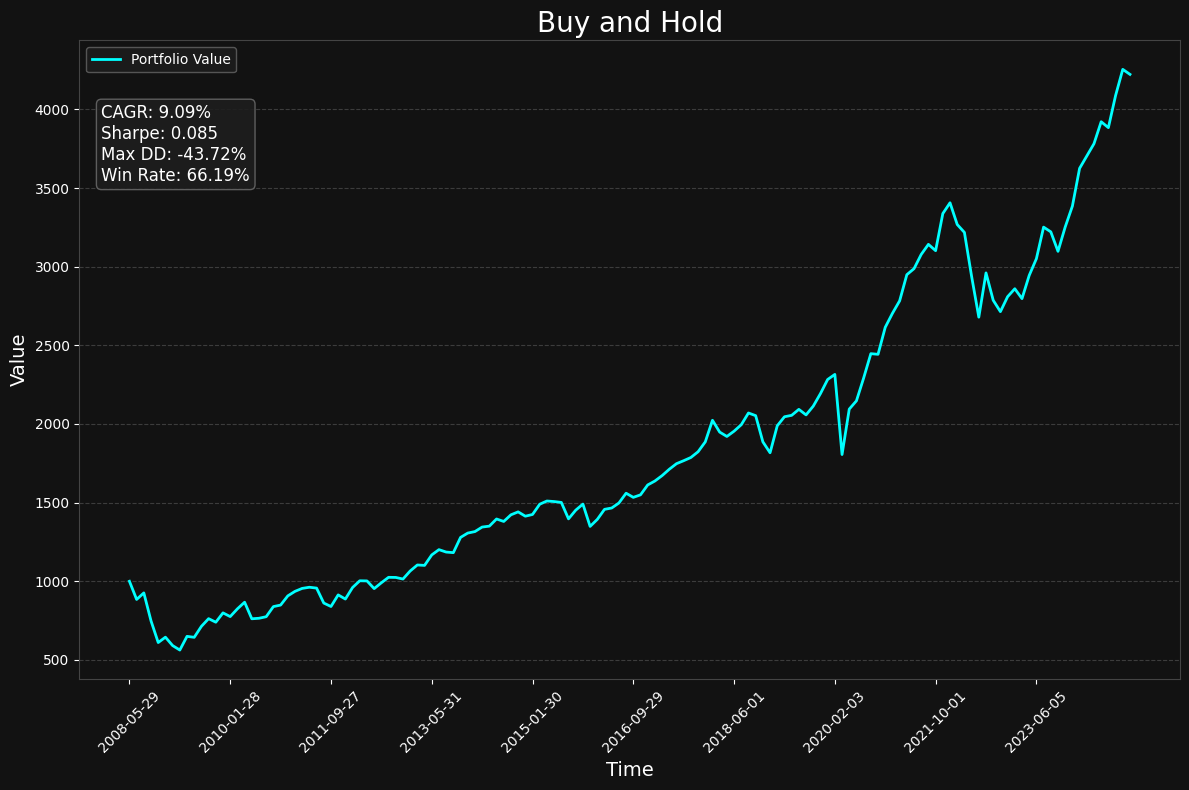

In [7]:
BUY_AND_HOLD_TICKER = "SPY"

cash = STARTING_CASH
buy_and_hold_values = []
buy_and_hold_days = []
amount = 0

adjust_time_window = adjust_days(COMPARISON_TIME_WINDOW)
adjust_rebalance_period = adjust_days(REBALANCE_PERIOD)

amount = cash / df.iloc[adjust_time_window][BUY_AND_HOLD_TICKER]
cash = 0

for i in range(adjust_time_window, len(df.index), REBALANCE_PERIOD):
    buy_and_hold_values.append(amount * df.iloc[i][BUY_AND_HOLD_TICKER])
    buy_and_hold_days.append(df.iloc[i]["Date"])

buy_and_hold_stats = calculate_portfolio_statistics(
    buy_and_hold_values, buy_and_hold_days
)

plot(
    buy_and_hold_values,
    buy_and_hold_days,
    "Buy and Hold",
    stats=buy_and_hold_stats,
)

In [8]:
print("Buy and Hold Key Metrics:")
print(f"CAGR: {buy_and_hold_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {buy_and_hold_stats['sharpe_ratio']}")
print(f"Max Drawdown: {buy_and_hold_stats['max_drawdown [%]']}%")
print(f"Win Rate: {buy_and_hold_stats['win_rate']}%")

Buy and Hold Key Metrics:
CAGR: 9.09%
Sharpe Ratio: 0.085
Max Drawdown: -43.72%
Win Rate: 66.19%


## GEM (Original)

The Global Equity Momentum (GEM) strategy, introduced by Gary Antonacci, systematically allocates capital to the asset class demonstrating the strongest relative performance over a fixed comparison time window. In this notebook, the original variant uses three instruments: **SPY** (U.S. equities), **VEU** (international equities), and **BIL** (short-term Treasury bills as the defensive asset). The portfolio is rebalanced at regular intervals (monthly or quarterly), shifting to the top-performing asset among these three. This dual momentum approach seeks to capture returns from strong trends in global equity markets while reducing volatility and drawdowns compared to passive investing.

In [9]:
def gem_sim(
    rebalance_period: int,
    comparison_time_window: int,
    tickers: list[str] = ORIGINAL_TICKERS,
    starting_cash: float = STARTING_CASH,
    transaction_cost: float = TRANSACTION_COST,
) -> tuple[list[float], list[str]]:
    """Simulate GEM strategy with given parameters."""
    strategy = MomentumStrategy(starting_cash)

    adjusted_rebalance_period = adjust_days(rebalance_period)
    adjusted_comparison_time_window = adjust_days(comparison_time_window)

    earliest_valid = find_earliest_valid_index(tickers)
    start_index = max(adjusted_comparison_time_window, earliest_valid)

    for i in range(start_index, len(df.index), adjusted_rebalance_period):
        value_change = strategy.calc_momentum(
            tickers, i, adjusted_comparison_time_window
        )
        best_performer = max(value_change, key=value_change.get)
        strategy.rebalance_portfolio(best_performer, i, transaction_cost)
        strategy.record_value(i)

    return strategy.values, strategy.days

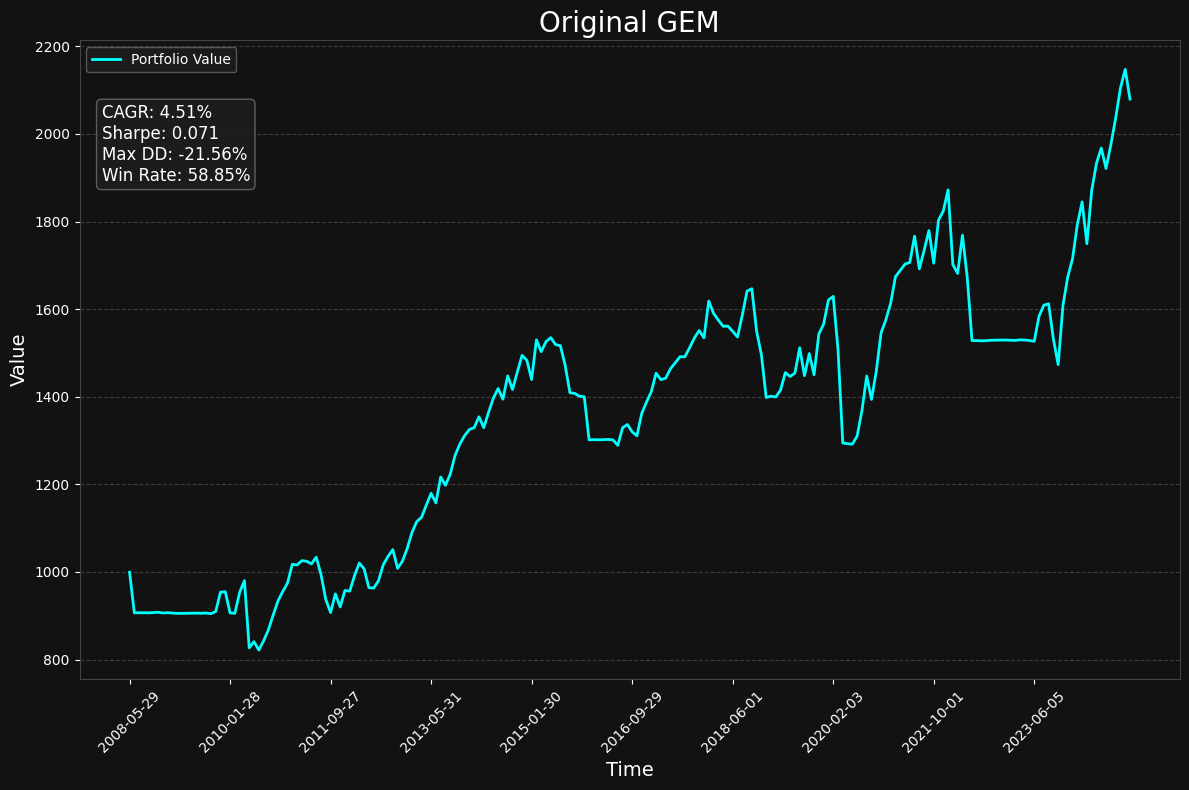

In [10]:
REBALANCE_PERIOD = 30  # in days
COMPARISON_TIME_WINDOW = 365  # in days

gem_original_values, gem_original_days = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW
)

gem_original_stats = calculate_portfolio_statistics(
    gem_original_values, gem_original_days
)

plot(
    gem_original_values,
    gem_original_days,
    "Original GEM",
    stats=gem_original_stats,
)

In [11]:
print("Original GEM Key Metrics:")
print(f"CAGR: {gem_original_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {gem_original_stats['sharpe_ratio']}")
print(f"Max Drawdown: {gem_original_stats['max_drawdown [%]']}%")
print(f"Win Rate: {gem_original_stats['win_rate']}%")

Original GEM Key Metrics:
CAGR: 4.51%
Sharpe Ratio: 0.071
Max Drawdown: -21.56%
Win Rate: 58.85%


## GEM (Expanded Tickers)

The expanded GEM strategy extends the base framework by including additional asset classes: **EEM** (emerging markets), **IAU** (gold), **QQQ** (Nasdaq-100), **TLT** (long-term U.S. Treasuries), and **VGK** (Europe), alongside **BIL**, **SPY**, and **VEU**. At each rebalancing window, the algorithm evaluates momentum across all eight ETFs and reallocates capital to the top performer. This broader approach tests momentum robustness in a multi-asset context, while also introducing higher switching complexity and potentially different behavior across market regimes.

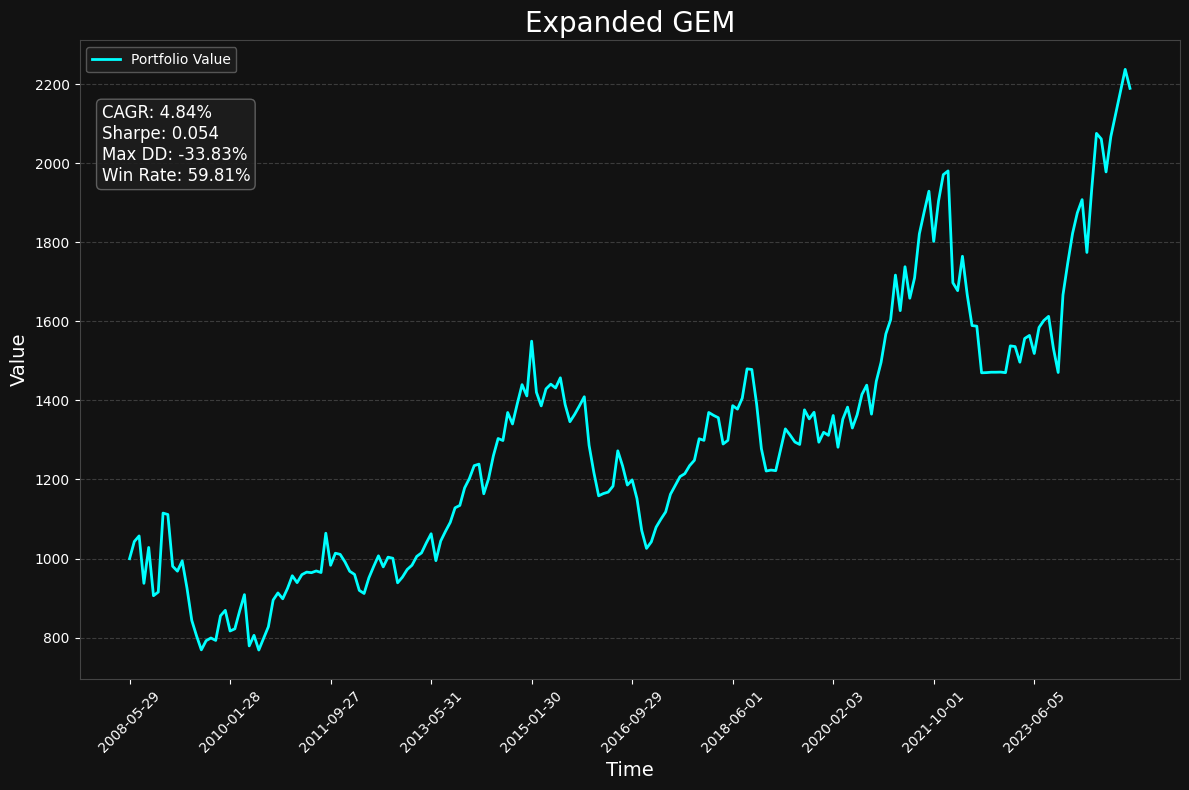

In [12]:
REBALANCE_PERIOD = 30  # in days
COMPARISON_TIME_WINDOW = 365  # in days

all_gem_original_values, all_gem_original_days = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW, EXTENDED_TICKERS
)

all_gem_original_stats = calculate_portfolio_statistics(
    all_gem_original_values, all_gem_original_days
)

plot(
    all_gem_original_values,
    all_gem_original_days,
    "Expanded GEM",
    stats=all_gem_original_stats,
)

In [13]:
print("Expanded GEM Key Metrics:")
print(f"CAGR: {all_gem_original_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {all_gem_original_stats['sharpe_ratio']}")
print(f"Max Drawdown: {all_gem_original_stats['max_drawdown [%]']}%")
print(f"Win Rate: {all_gem_original_stats['win_rate']}%")

Expanded GEM Key Metrics:
CAGR: 4.84%
Sharpe Ratio: 0.054
Max Drawdown: -33.83%
Win Rate: 59.81%


## GEM with 90-Day Rebalancing 

This variant reduces the frequency of portfolio adjustments by rebalancing once per quarter (approximately 90 days) instead of monthly. While the classic GEM approach typically uses monthly rebalancing to capture momentum signals more dynamically, quarterly rebalancing offers potential advantages: reduced transaction costs, lower turnover, and less sensitivity to short-term market noise. Research suggests that less frequent rebalancing can still capture medium-term momentum trends while potentially improving risk-adjusted returns by avoiding whipsaw trades during volatile periods.

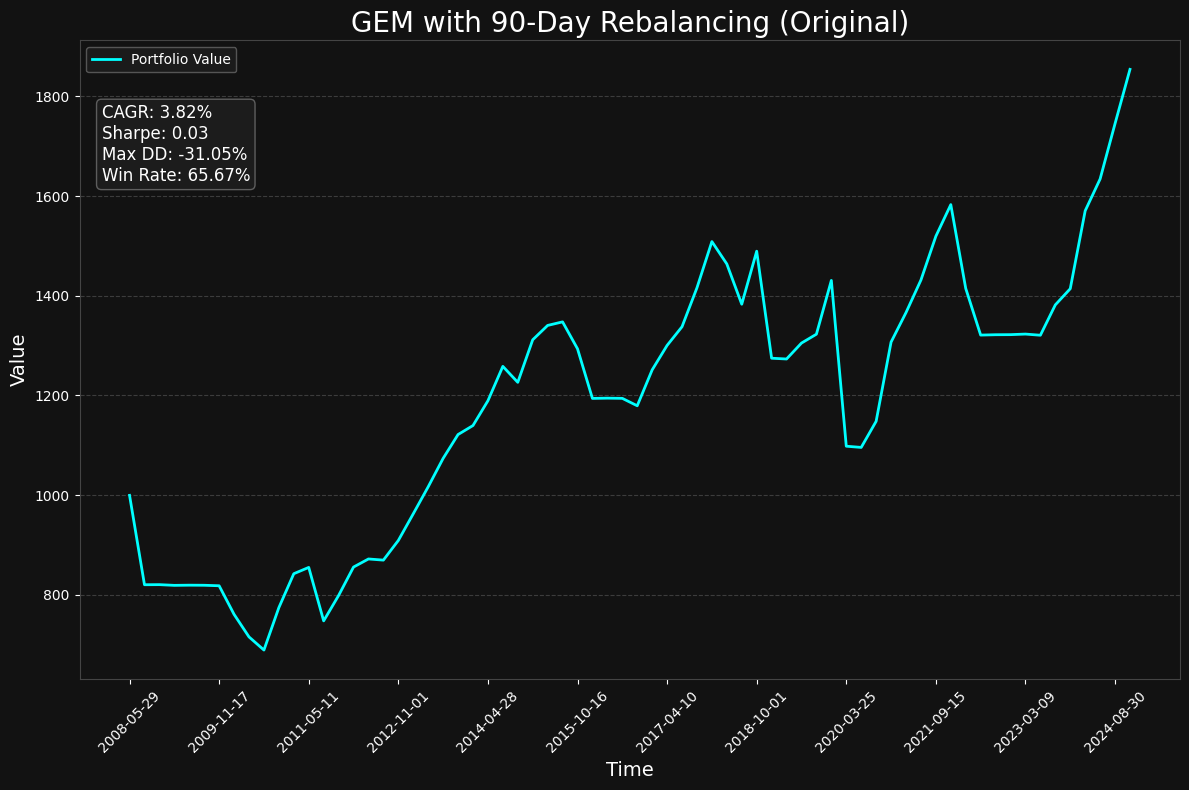

In [14]:
REBALANCE_PERIOD = 30 * 3  # in days
COMPARISON_TIME_WINDOW = 365  # in days

gem_values_long_period, gem_days_long_period = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW
)

gem_long_period_stats = calculate_portfolio_statistics(
    gem_values_long_period, gem_days_long_period
)

plot(
    gem_values_long_period,
    gem_days_long_period,
    "GEM with 90-Day Rebalancing (Original)",
    stats=gem_long_period_stats,
)

In [15]:
print("GEM with 90-Day Rebalancing (Original) Key Metrics:")
print(f"CAGR: {gem_long_period_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {gem_long_period_stats['sharpe_ratio']}")
print(f"Max Drawdown: {gem_long_period_stats['max_drawdown [%]']}%")
print(f"Win Rate: {gem_long_period_stats['win_rate']}%")

GEM with 90-Day Rebalancing (Original) Key Metrics:
CAGR: 3.82%
Sharpe Ratio: 0.03
Max Drawdown: -31.05%
Win Rate: 65.67%


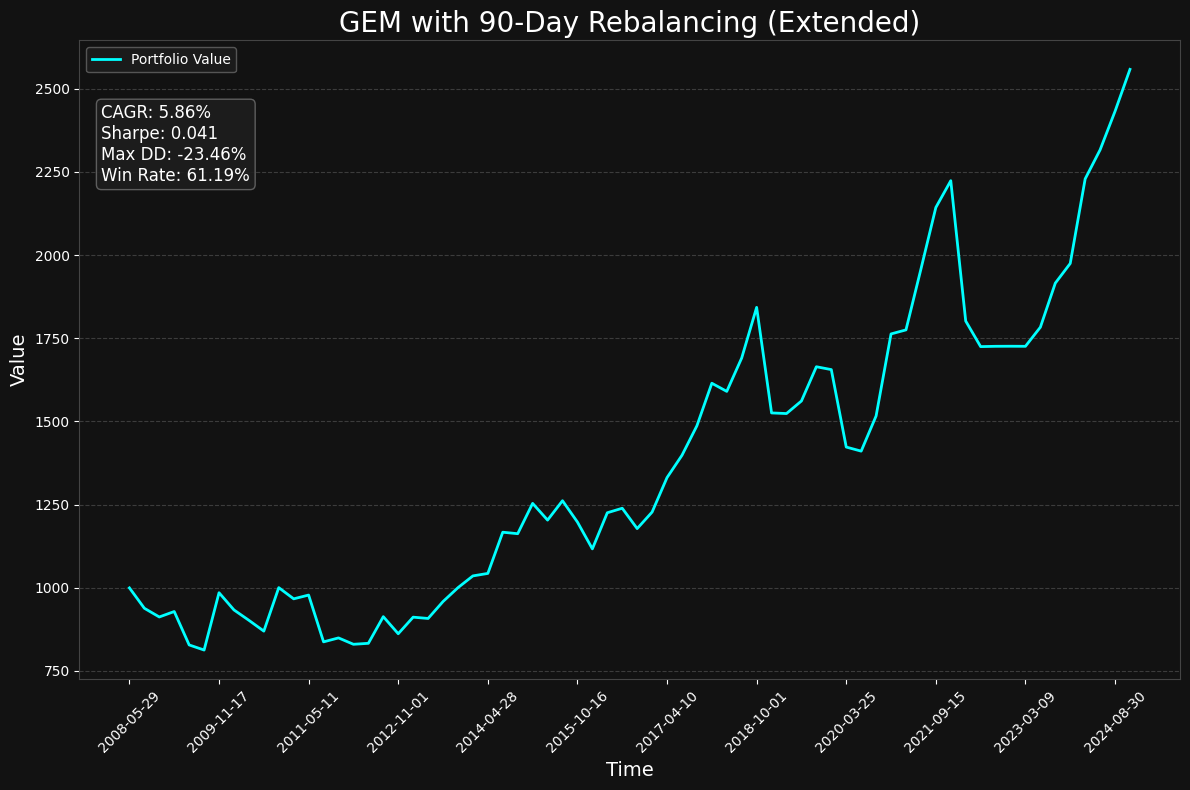

In [16]:
REBALANCE_PERIOD = 30 * 3  # in days
COMPARISON_TIME_WINDOW = 365  # in days

all_gem_values_long_period, all_gem_days_long_period = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW, EXTENDED_TICKERS
)

all_gem_long_period_stats = calculate_portfolio_statistics(
    all_gem_values_long_period, all_gem_days_long_period
)

plot(
    all_gem_values_long_period,
    all_gem_days_long_period,
    "GEM with 90-Day Rebalancing (Extended)",
    stats=all_gem_long_period_stats,
)

In [17]:
print("GEM with 90-Day Rebalancing (Extended) Key Metrics:")
print(f"CAGR: {all_gem_long_period_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {all_gem_long_period_stats['sharpe_ratio']}")
print(f"Max Drawdown: {all_gem_long_period_stats['max_drawdown [%]']}%")
print(f"Win Rate: {all_gem_long_period_stats['win_rate']}%")

GEM with 90-Day Rebalancing (Extended) Key Metrics:
CAGR: 5.86%
Sharpe Ratio: 0.041
Max Drawdown: -23.46%
Win Rate: 61.19%


## GEM with 15-Day Rebalancing Period

This variant tests a more aggressive rebalancing approach by updating portfolio positions every 15 days, approximately twice per month. Some momentum research suggests that rebalancing on multiple dates within a month—rather than once on a fixed date—can reduce timing risk and smooth out returns. The strategy maintains the standard 12-month lookback window but checks momentum signals more frequently, potentially capturing shorter-term trend shifts before they fully reverse.

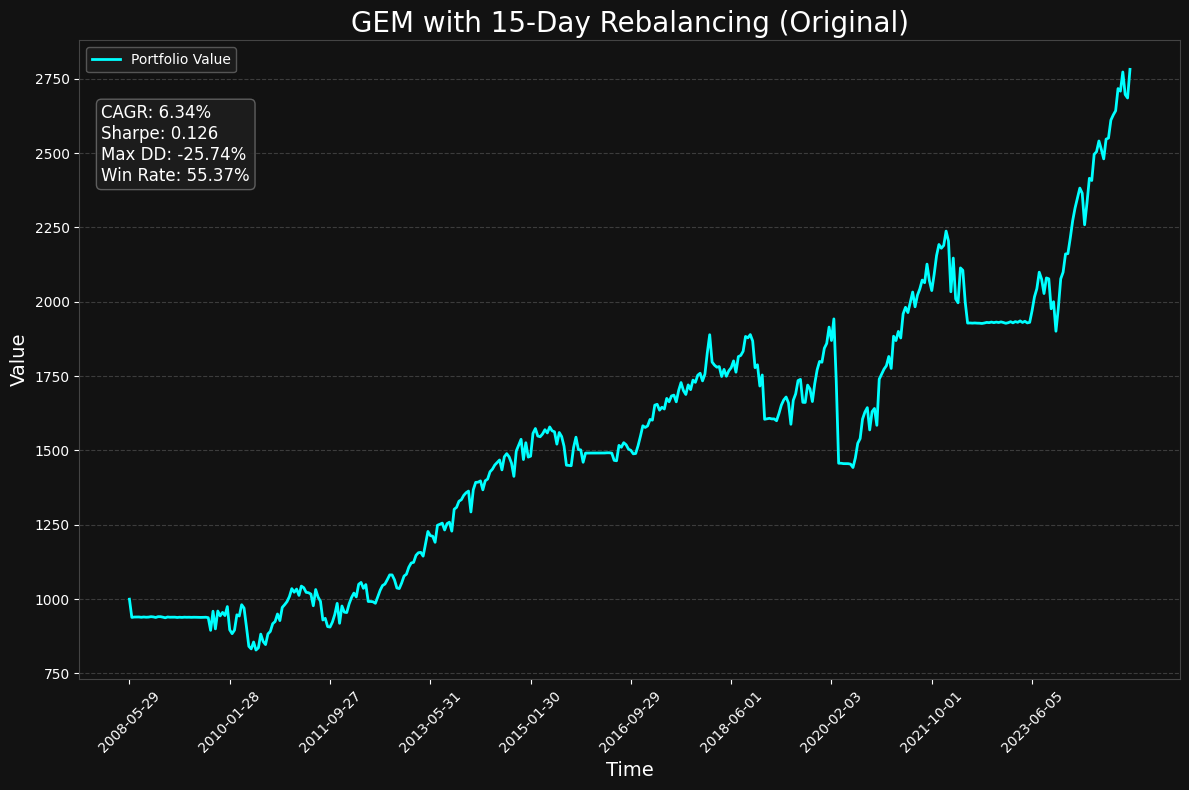

In [18]:
REBALANCE_PERIOD = 30 // 2  # in days
COMPARISON_TIME_WINDOW = 365  # in days

gem_values_short_period, gem_days_short_period = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW
)

gem_short_period_stats = calculate_portfolio_statistics(
    gem_values_short_period, gem_days_short_period
)

plot(
    gem_values_short_period,
    gem_days_short_period,
    "GEM with 15-Day Rebalancing (Original)",
    stats=gem_short_period_stats,
)

In [19]:
print("GEM with 15-Day Rebalancing (Original) Key Metrics:")
print(f"CAGR: {gem_short_period_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {gem_short_period_stats['sharpe_ratio']}")
print(f"Max Drawdown: {gem_short_period_stats['max_drawdown [%]']}%")
print(f"Win Rate: {gem_short_period_stats['win_rate']}%")

GEM with 15-Day Rebalancing (Original) Key Metrics:
CAGR: 6.34%
Sharpe Ratio: 0.126
Max Drawdown: -25.74%
Win Rate: 55.37%


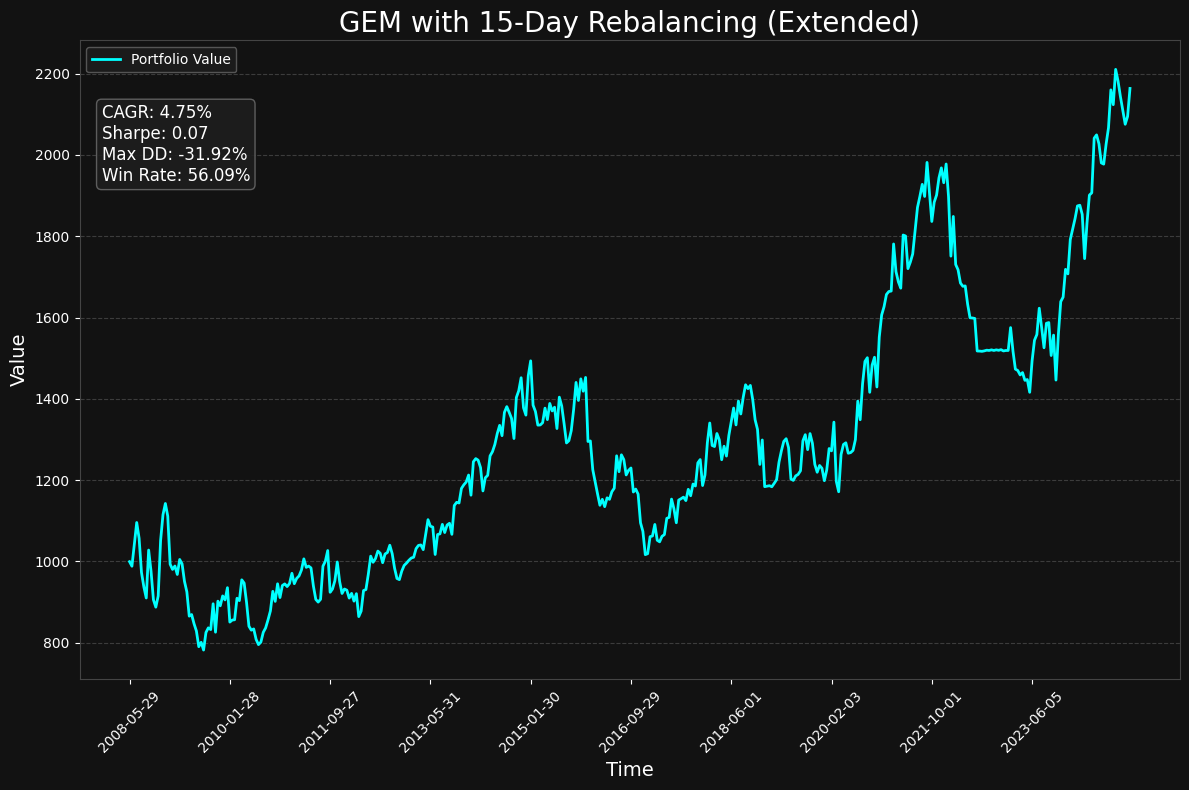

In [20]:
REBALANCE_PERIOD = 30 // 2  # in days
COMPARISON_TIME_WINDOW = 365  # in days

all_gem_values_short_period, all_gem_days_short_period = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW, EXTENDED_TICKERS
)

all_gem_short_period_stats = calculate_portfolio_statistics(
    all_gem_values_short_period, all_gem_days_short_period
)

plot(
    all_gem_values_short_period,
    all_gem_days_short_period,
    "GEM with 15-Day Rebalancing (Extended)",
    stats=all_gem_short_period_stats,
)

In [21]:
print("GEM with 15-Day Rebalancing (Extended) Key Metrics:")
print(f"CAGR: {all_gem_short_period_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {all_gem_short_period_stats['sharpe_ratio']}")
print(f"Max Drawdown: {all_gem_short_period_stats['max_drawdown [%]']}%")
print(f"Win Rate: {all_gem_short_period_stats['win_rate']}%")

GEM with 15-Day Rebalancing (Extended) Key Metrics:
CAGR: 4.75%
Sharpe Ratio: 0.07
Max Drawdown: -31.92%
Win Rate: 56.09%


## GEM with 3-Year Comparison Time Window

This variant extends the lookback period to 36 months (3 years) while maintaining monthly rebalancing. Where the classic GEM uses a 12-month momentum window, this approach evaluates asset performance over a significantly longer horizon to capture multi-year trends and filter out shorter-term volatility. The strategy aims to identify more persistent, longer-term winners while potentially reducing the frequency of position switches caused by temporary market fluctuations.​

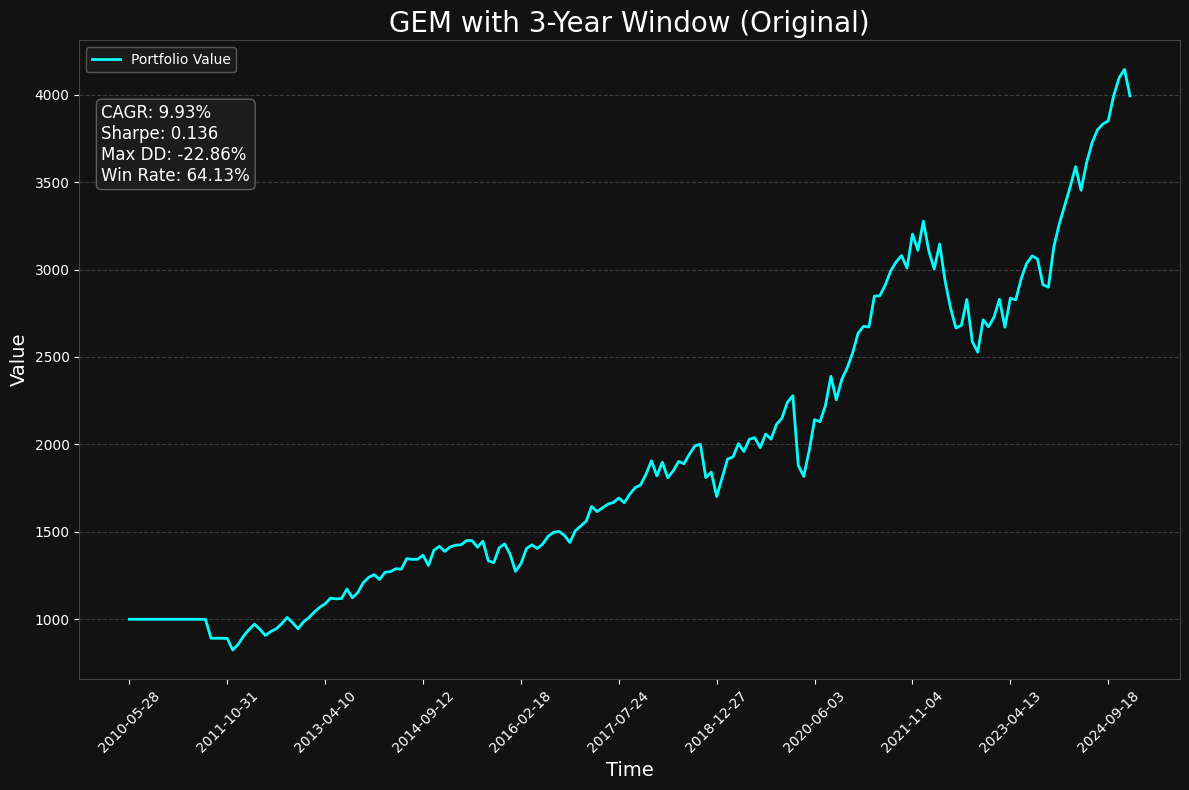

In [22]:
REBALANCE_PERIOD = 30  # in days
COMPARISON_TIME_WINDOW = 365 * 3  # in days

gem_values_bigger_window, gem_days_bigger_window = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW
)

gem_bigger_window_stats = calculate_portfolio_statistics(
    gem_values_bigger_window, gem_days_bigger_window
)

plot(
    gem_values_bigger_window,
    gem_days_bigger_window,
    "GEM with 3-Year Window (Original)",
    stats=gem_bigger_window_stats,
)

In [23]:
print("GEM with 3-Year Window (Original) Key Metrics:")
print(f"CAGR: {gem_bigger_window_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {gem_bigger_window_stats['sharpe_ratio']}")
print(f"Max Drawdown: {gem_bigger_window_stats['max_drawdown [%]']}%")
print(f"Win Rate: {gem_bigger_window_stats['win_rate']}%")

GEM with 3-Year Window (Original) Key Metrics:
CAGR: 9.93%
Sharpe Ratio: 0.136
Max Drawdown: -22.86%
Win Rate: 64.13%


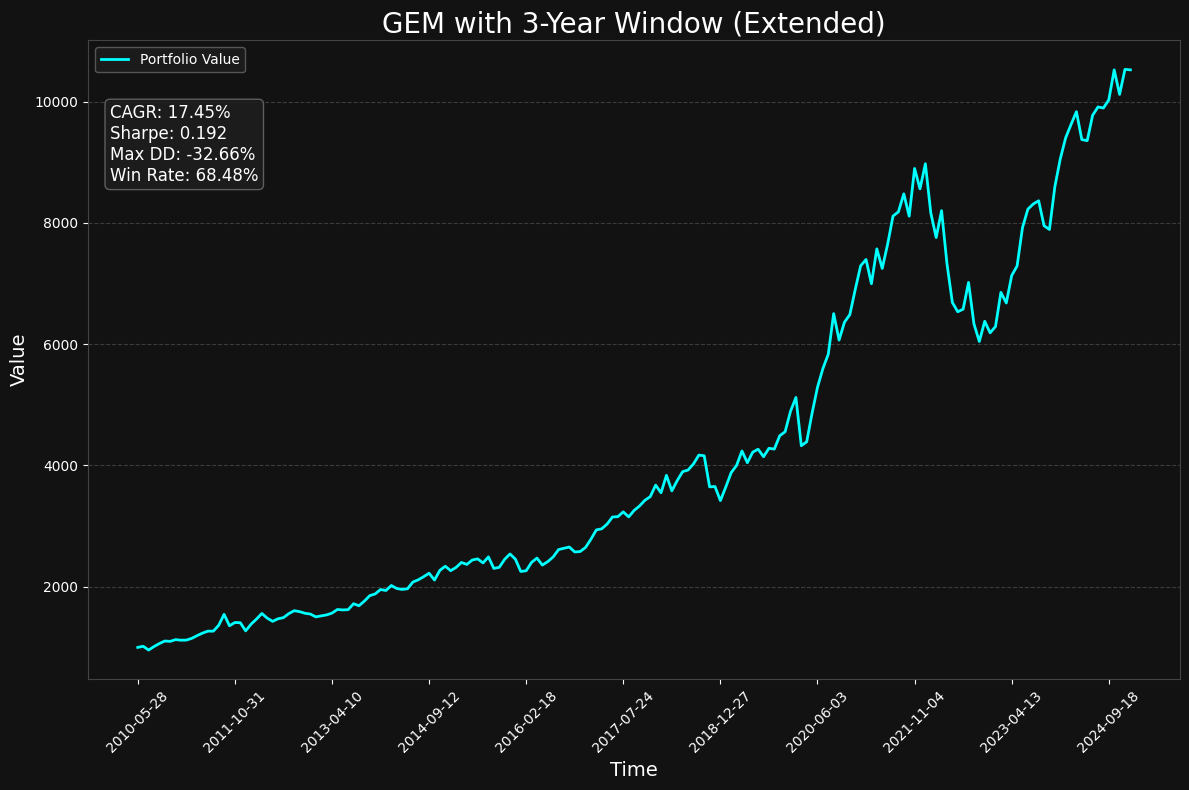

In [24]:
REBALANCE_PERIOD = 30  # in days
COMPARISON_TIME_WINDOW = 365 * 3  # in days

all_gem_values_bigger_window, all_gem_days_bigger_window = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW, EXTENDED_TICKERS
)

all_gem_bigger_window_stats = calculate_portfolio_statistics(
    all_gem_values_bigger_window, all_gem_days_bigger_window
)

plot(
    all_gem_values_bigger_window,
    all_gem_days_bigger_window,
    "GEM with 3-Year Window (Extended)",
    stats=all_gem_bigger_window_stats,
)

In [25]:
print("GEM with 3-Year Window (Extended) Key Metrics:")
print(f"CAGR: {all_gem_bigger_window_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {all_gem_bigger_window_stats['sharpe_ratio']}")
print(f"Max Drawdown: {all_gem_bigger_window_stats['max_drawdown [%]']}%")
print(f"Win Rate: {all_gem_bigger_window_stats['win_rate']}%")

GEM with 3-Year Window (Extended) Key Metrics:
CAGR: 17.45%
Sharpe Ratio: 0.192
Max Drawdown: -32.66%
Win Rate: 68.48%


## GEM with 6-Month Comparison Time Window

This variant shortens the lookback period to 6 months while maintaining monthly rebalancing, testing whether shorter-term momentum signals can enhance responsiveness to market trends. Research on momentum strategies indicates that momentum phenomena exist across various timeframes, with many studies finding significant effects at 6 to 12-month horizons. A 6-month window aims to capture more recent price trends and potentially react faster to changing market conditions compared to the traditional 12-month approach.

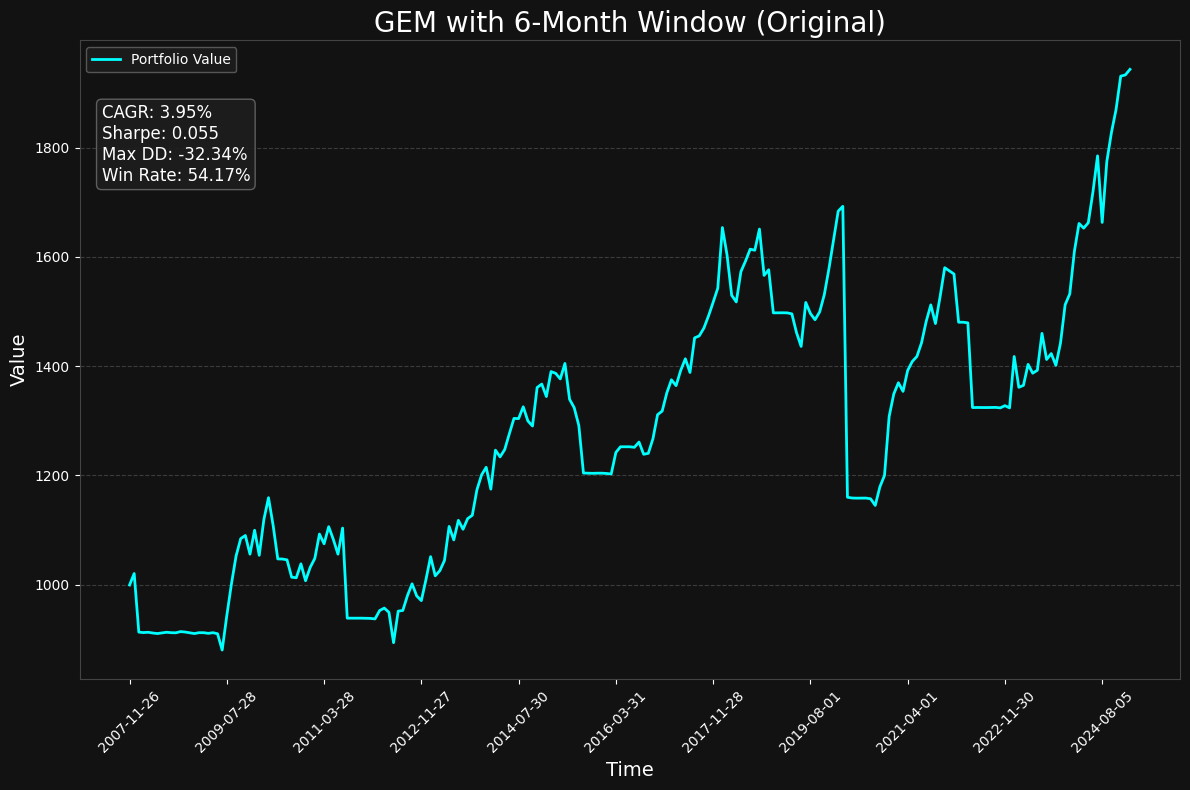

In [26]:
REBALANCE_PERIOD = 30  # in days
COMPARISON_TIME_WINDOW = 365 // 2  # in days

gem_values_smaller_window, gem_days_smaller_window = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW
)

gem_smaller_window_stats = calculate_portfolio_statistics(
    gem_values_smaller_window, gem_days_smaller_window
)

plot(
    gem_values_smaller_window,
    gem_days_smaller_window,
    "GEM with 6-Month Window (Original)",
    stats=gem_smaller_window_stats,
)

In [27]:
print("GEM with 6-Month Window (Original) Key Metrics:")
print(f"CAGR: {gem_smaller_window_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {gem_smaller_window_stats['sharpe_ratio']}")
print(f"Max Drawdown: {gem_smaller_window_stats['max_drawdown [%]']}%")
print(f"Win Rate: {gem_smaller_window_stats['win_rate']}%")

GEM with 6-Month Window (Original) Key Metrics:
CAGR: 3.95%
Sharpe Ratio: 0.055
Max Drawdown: -32.34%
Win Rate: 54.17%


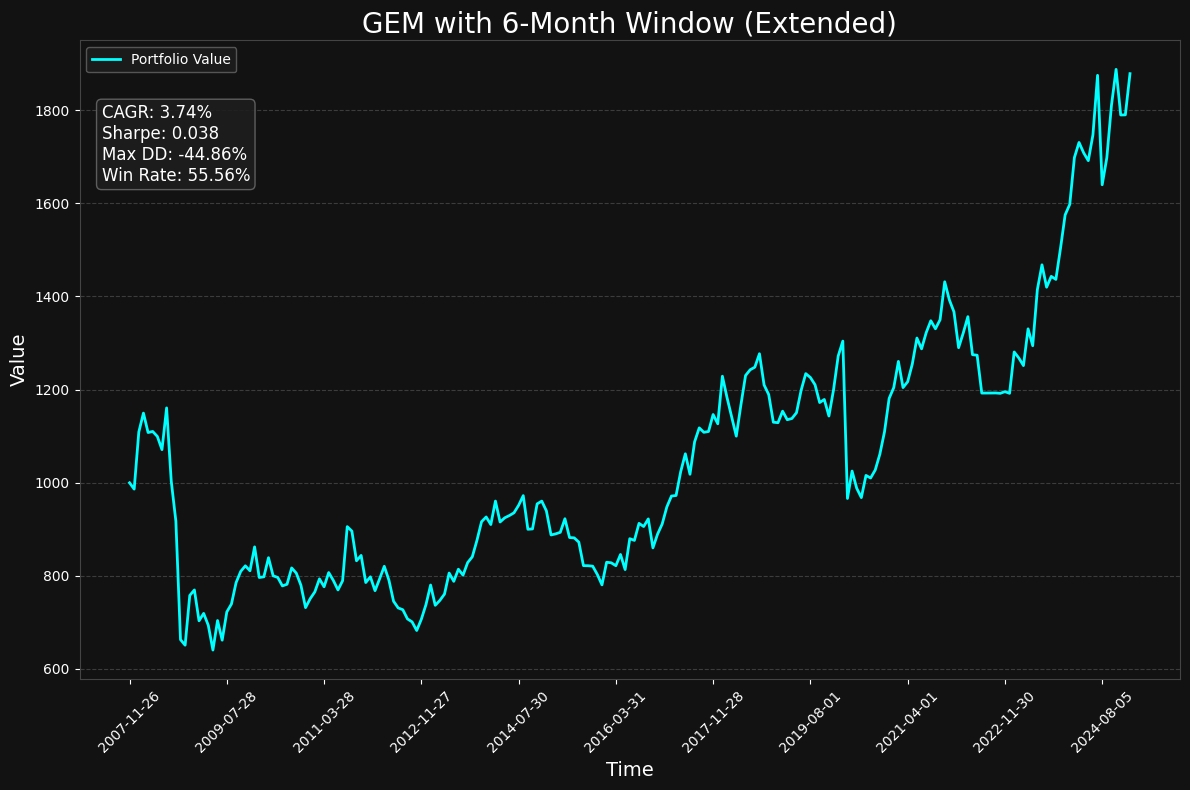

In [28]:
REBALANCE_PERIOD = 30  # in days
COMPARISON_TIME_WINDOW = 365 // 2  # in days

all_gem_values_smaller_window, all_gem_days_smaller_window = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW, EXTENDED_TICKERS
)

all_gem_smaller_window_stats = calculate_portfolio_statistics(
    all_gem_values_smaller_window, all_gem_days_smaller_window
)

plot(
    all_gem_values_smaller_window,
    all_gem_days_smaller_window,
    "GEM with 6-Month Window (Extended)",
    stats=all_gem_smaller_window_stats,
)

In [29]:
print("GEM with 6-Month Window (Extended) Key Metrics:")
print(f"CAGR: {all_gem_smaller_window_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {all_gem_smaller_window_stats['sharpe_ratio']}")
print(f"Max Drawdown: {all_gem_smaller_window_stats['max_drawdown [%]']}%")
print(f"Win Rate: {all_gem_smaller_window_stats['win_rate']}%")

GEM with 6-Month Window (Extended) Key Metrics:
CAGR: 3.74%
Sharpe Ratio: 0.038
Max Drawdown: -44.86%
Win Rate: 55.56%


## GEM Long-Term Trader

This variant targets long-term trend followers by combining quarterly rebalancing with a 3-year comparison window. Both parameters are tripled from the standard monthly/12-month GEM approach, creating a strategy designed for patient investors seeking to capture multi-year secular trends while minimizing trading activity. This configuration reduces transaction costs significantly—potentially executing only 4-5 trades per year—while focusing on assets demonstrating sustained, long-term momentum. The extended lookback period filters out medium-term volatility and market noise, identifying only the most persistent winners. However, this approach sacrifices responsiveness: the strategy may be slow to exit deteriorating positions or enter new trends, potentially missing shorter-term opportunities or enduring prolonged drawdowns during major market regime changes. This variant is ideal for testing whether a truly long-term, low-turnover momentum approach can match or exceed more active implementations.​

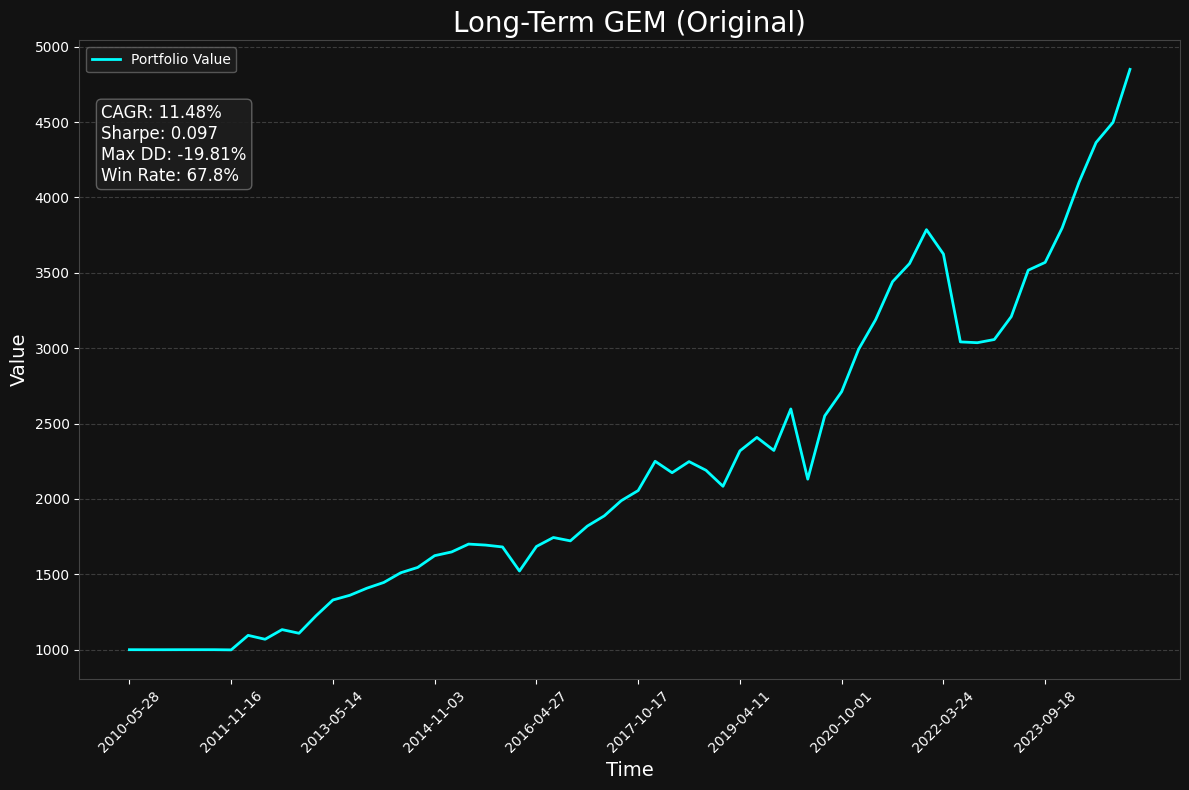

In [30]:
REBALANCE_PERIOD = 30 * 3  # in days
COMPARISON_TIME_WINDOW = 365 * 3  # in days

gem_values_long_term, gem_days_long_term = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW
)

gem_long_term_stats = calculate_portfolio_statistics(
    gem_values_long_term, gem_days_long_term
)

plot(
    gem_values_long_term,
    gem_days_long_term,
    "Long-Term GEM (Original)",
    stats=gem_long_term_stats,
)

In [31]:
print("Long-Term GEM (Original) Key Metrics:")
print(f"CAGR: {gem_long_term_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {gem_long_term_stats['sharpe_ratio']}")
print(f"Max Drawdown: {gem_long_term_stats['max_drawdown [%]']}%")
print(f"Win Rate: {gem_long_term_stats['win_rate']}%")

Long-Term GEM (Original) Key Metrics:
CAGR: 11.48%
Sharpe Ratio: 0.097
Max Drawdown: -19.81%
Win Rate: 67.8%


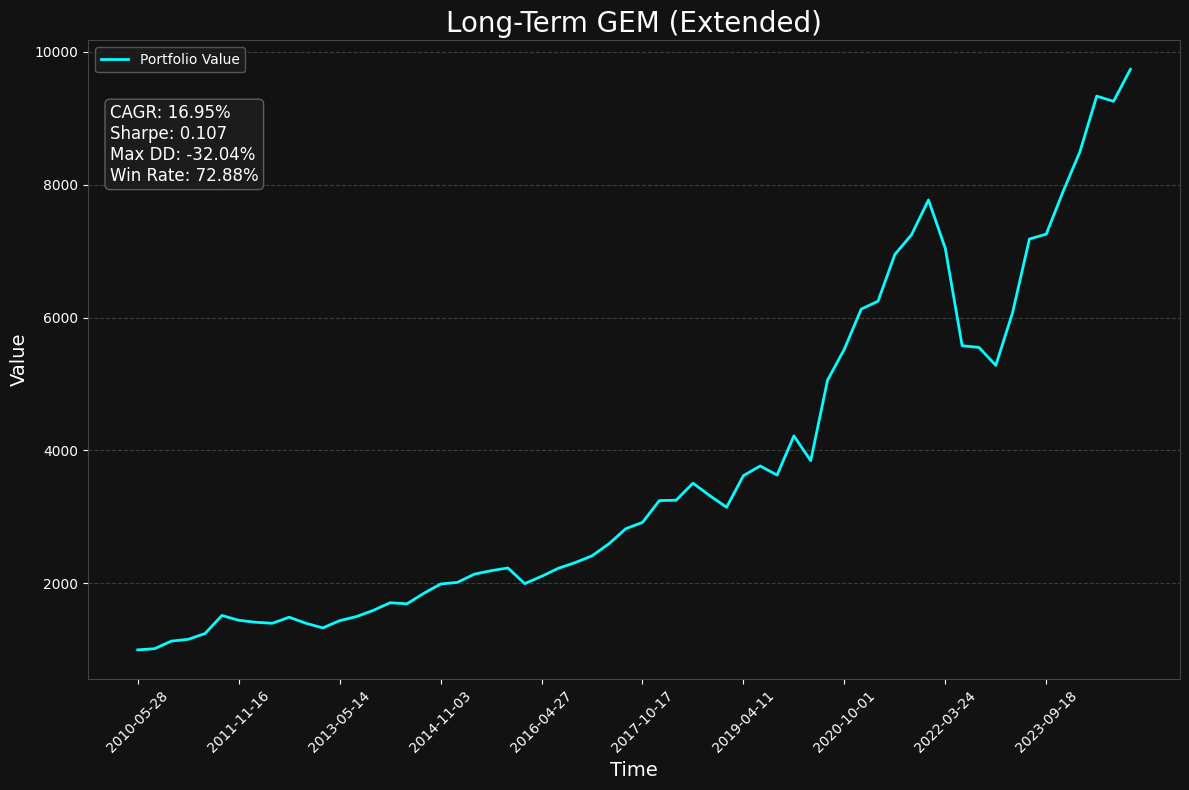

In [32]:
REBALANCE_PERIOD = 30 * 3  # in days
COMPARISON_TIME_WINDOW = 365 * 3  # in days

all_gem_values_long_term, all_gem_days_long_term = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW, EXTENDED_TICKERS
)

all_gem_long_term_stats = calculate_portfolio_statistics(
    all_gem_values_long_term, all_gem_days_long_term
)

plot(
    all_gem_values_long_term,
    all_gem_days_long_term,
    "Long-Term GEM (Extended)",
    stats=all_gem_long_term_stats,
)

In [33]:
print("Long-Term GEM (Extended) Key Metrics:")
print(f"CAGR: {all_gem_long_term_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {all_gem_long_term_stats['sharpe_ratio']}")
print(f"Max Drawdown: {all_gem_long_term_stats['max_drawdown [%]']}%")
print(f"Win Rate: {all_gem_long_term_stats['win_rate']}%")

Long-Term GEM (Extended) Key Metrics:
CAGR: 16.95%
Sharpe Ratio: 0.107
Max Drawdown: -32.04%
Win Rate: 72.88%


## GEM Short-Term Trader

This aggressive variant cuts both parameters in half, using 15-day rebalancing with a 6-month comparison window to capture shorter-term momentum signals and react quickly to changing market conditions. By evaluating recent performance over just six months and adjusting positions twice per month, this strategy aims to exploit faster-moving trends and exit positions earlier when momentum fades. Academic research shows momentum effects exist across various timeframes, with some studies finding profitability in periods ranging from one to twelve months. However, the short-term approach faces significant challenges: higher transaction costs from frequent trading, increased sensitivity to market noise and whipsaws during volatile periods, and the risk of overreacting to temporary price fluctuations rather than genuine trend shifts. This variant tests whether faster adaptation and more responsive positioning can generate superior risk-adjusted returns or simply add friction and instability to the momentum signal.​

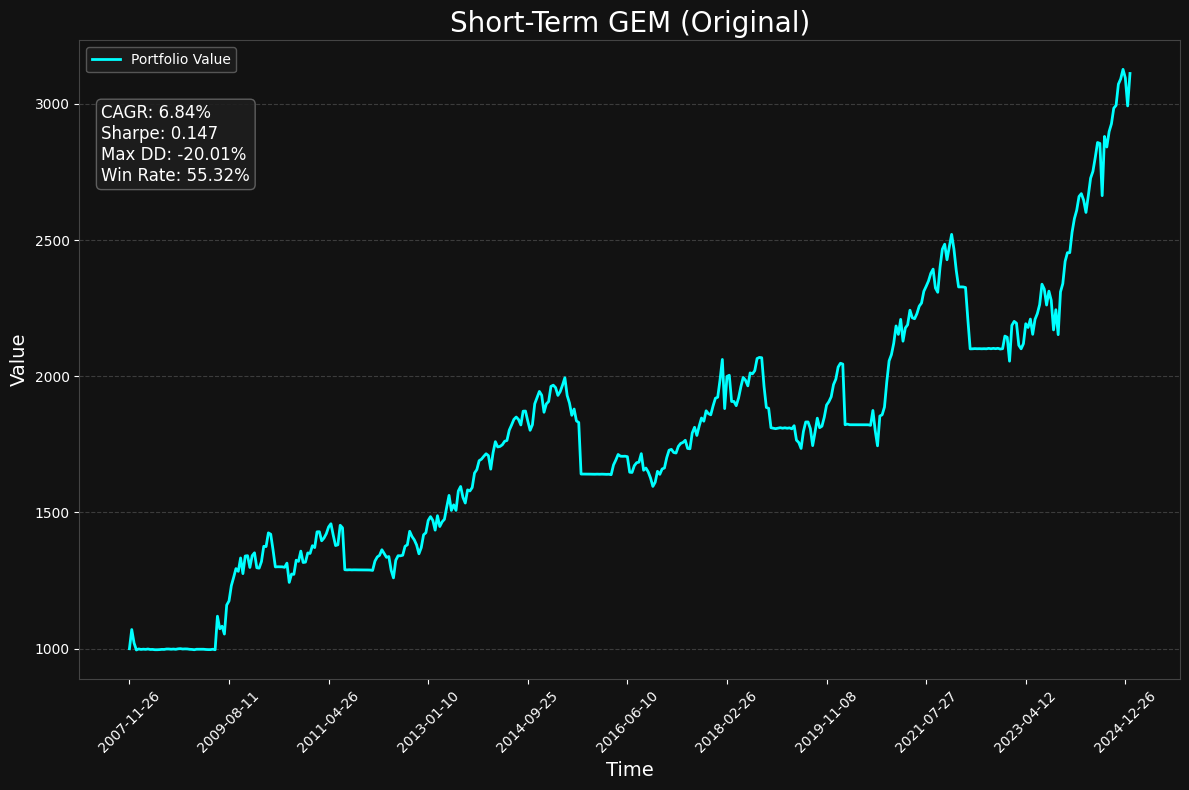

In [34]:
REBALANCE_PERIOD = 30 // 2  # in days
COMPARISON_TIME_WINDOW = 365 // 2  # in days

gem_values_short_term, gem_days_short_term = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW
)

gem_short_term_stats = calculate_portfolio_statistics(
    gem_values_short_term, gem_days_short_term
)

plot(
    gem_values_short_term,
    gem_days_short_term,
    "Short-Term GEM (Original)",
    stats=gem_short_term_stats,
)

In [35]:
print("Short-Term GEM (Original) Key Metrics:")
print(f"CAGR: {gem_short_term_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {gem_short_term_stats['sharpe_ratio']}")
print(f"Max Drawdown: {gem_short_term_stats['max_drawdown [%]']}%")
print(f"Win Rate: {gem_short_term_stats['win_rate']}%")

Short-Term GEM (Original) Key Metrics:
CAGR: 6.84%
Sharpe Ratio: 0.147
Max Drawdown: -20.01%
Win Rate: 55.32%


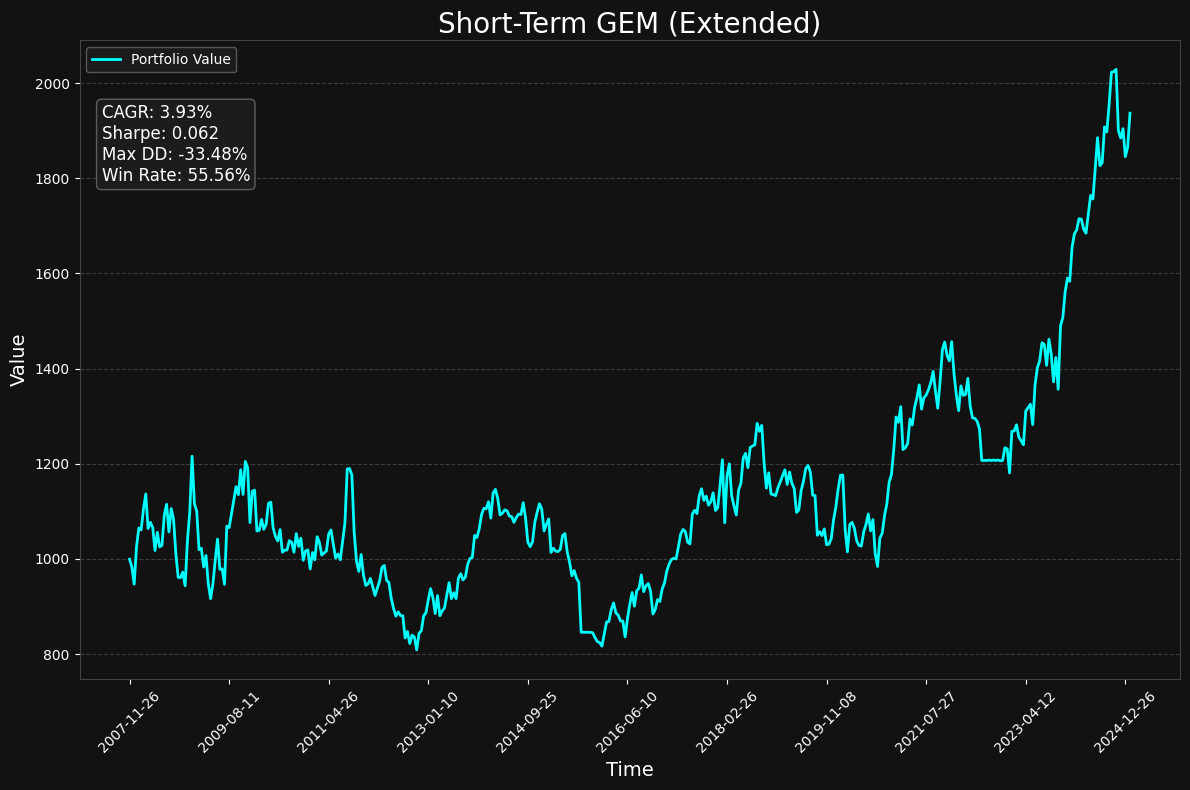

In [36]:
REBALANCE_PERIOD = 30 // 2  # in days
COMPARISON_TIME_WINDOW = 365 // 2  # in days

all_gem_values_short_term, all_gem_days_short_term = gem_sim(
    REBALANCE_PERIOD, COMPARISON_TIME_WINDOW, EXTENDED_TICKERS
)

all_gem_short_term_stats = calculate_portfolio_statistics(
    all_gem_values_short_term, all_gem_days_short_term
)

plot(
    all_gem_values_short_term,
    all_gem_days_short_term,
    "Short-Term GEM (Extended)",
    stats=all_gem_short_term_stats,
)

In [37]:
print("Short-Term GEM (Extended) Key Metrics:")
print(f"CAGR: {all_gem_short_term_stats['cagr [%]']}%")
print(f"Sharpe Ratio: {all_gem_short_term_stats['sharpe_ratio']}")
print(f"Max Drawdown: {all_gem_short_term_stats['max_drawdown [%]']}%")
print(f"Win Rate: {all_gem_short_term_stats['win_rate']}%")

Short-Term GEM (Extended) Key Metrics:
CAGR: 3.93%
Sharpe Ratio: 0.062
Max Drawdown: -33.48%
Win Rate: 55.56%


## Statistics

,Buy and Hold,Gem (Original),Gem (Extended),Long period,Long period (Extended),Short period,Short period (Extended),Big window,Big window (Extended),Small window,Small window (Extended),Long-term,Long-term (Extended),Short-term,Short-term (Extended)
total_return [%],322.250000,108.080000,119.100000,85.510000,155.970000,178.300000,116.470000,299.520000,952.780000,94.410000,88.000000,385.220000,873.920000,211.340000,93.760000
cagr [%],9.090000,4.510000,4.840000,3.820000,5.860000,6.340000,4.750000,9.930000,17.450000,3.950000,3.740000,11.480000,16.950000,6.840000,3.930000
annual_volatility [%],107.210000,63.700000,90.260000,126.410000,142.040000,50.210000,67.850000,72.990000,90.830000,71.630000,97.610000,118.840000,158.360000,46.490000,63.150000
max_drawdown [%],-43.720000,-21.560000,-33.830000,-31.050000,-23.460000,-25.740000,-31.920000,-22.860000,-32.660000,-32.340000,-44.860000,-19.810000,-32.040000,-20.010000,-33.480000
-,---,---,---,---,---,---,---,---,---,---,---,---,---,---,---
rising_days,92,123,125,44,41,232,235,118,126,117,120,40,43,239,240
falling_days,47,82,83,23,26,175,184,60,58,88,95,16,16,175,188
flat_days,0,4,1,0,0,12,0,6,0,11,1,3,0,18,4
avg_daily_return [%],1.205000,0.408000,0.488000,1.157000,1.691000,0.280000,0.247000,0.830000,1.402000,0.386000,0.430000,2.909000,4.265000,0.293000,0.208000
avg_daily_gain [%],4.103000,2.342000,3.415000,4.652000,6.143000,1.849000,2.601000,2.982000,3.950000,2.434000,3.674000,6.025000,7.941000,1.699000,2.415000


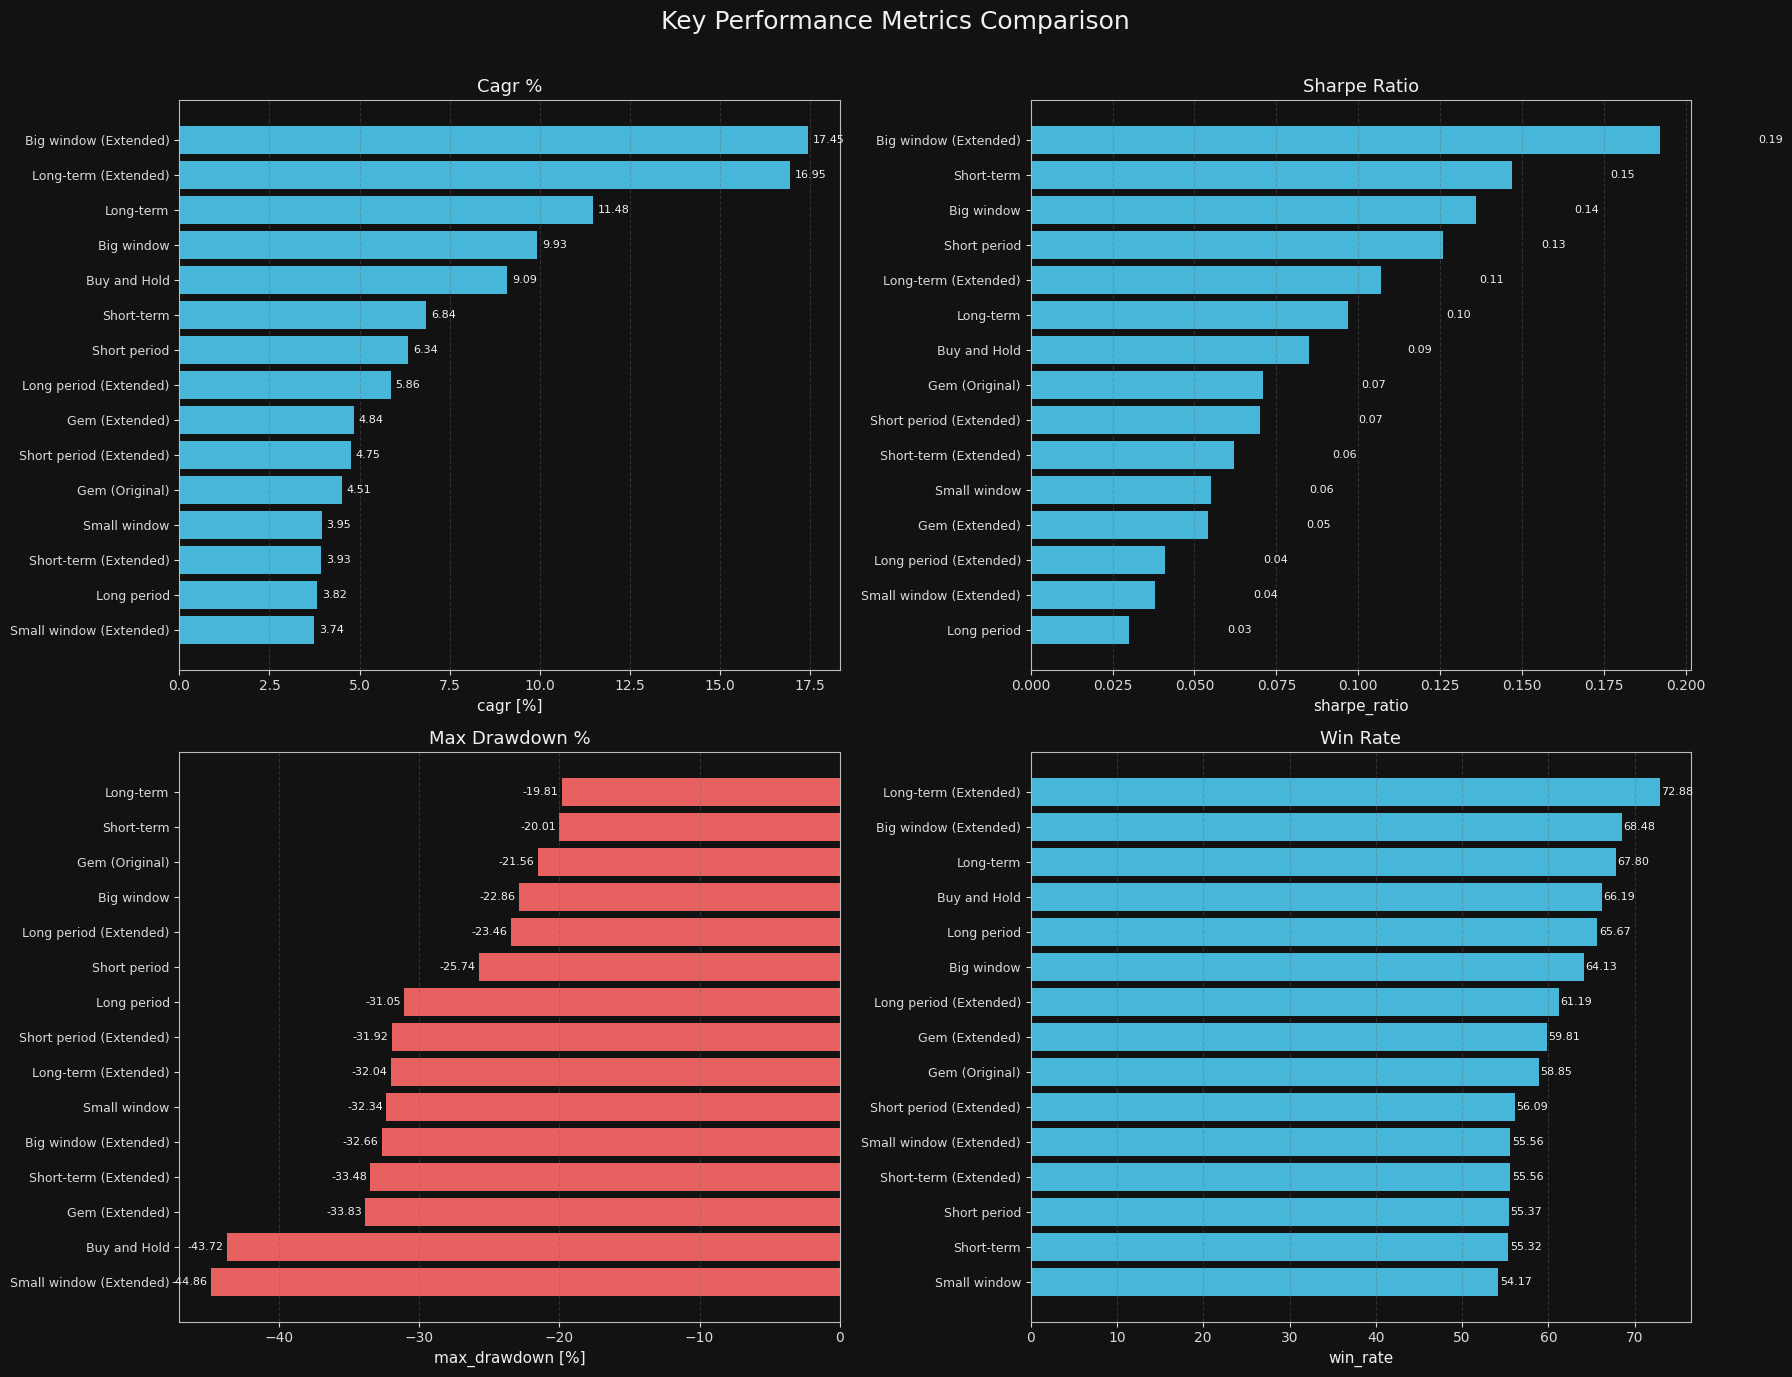

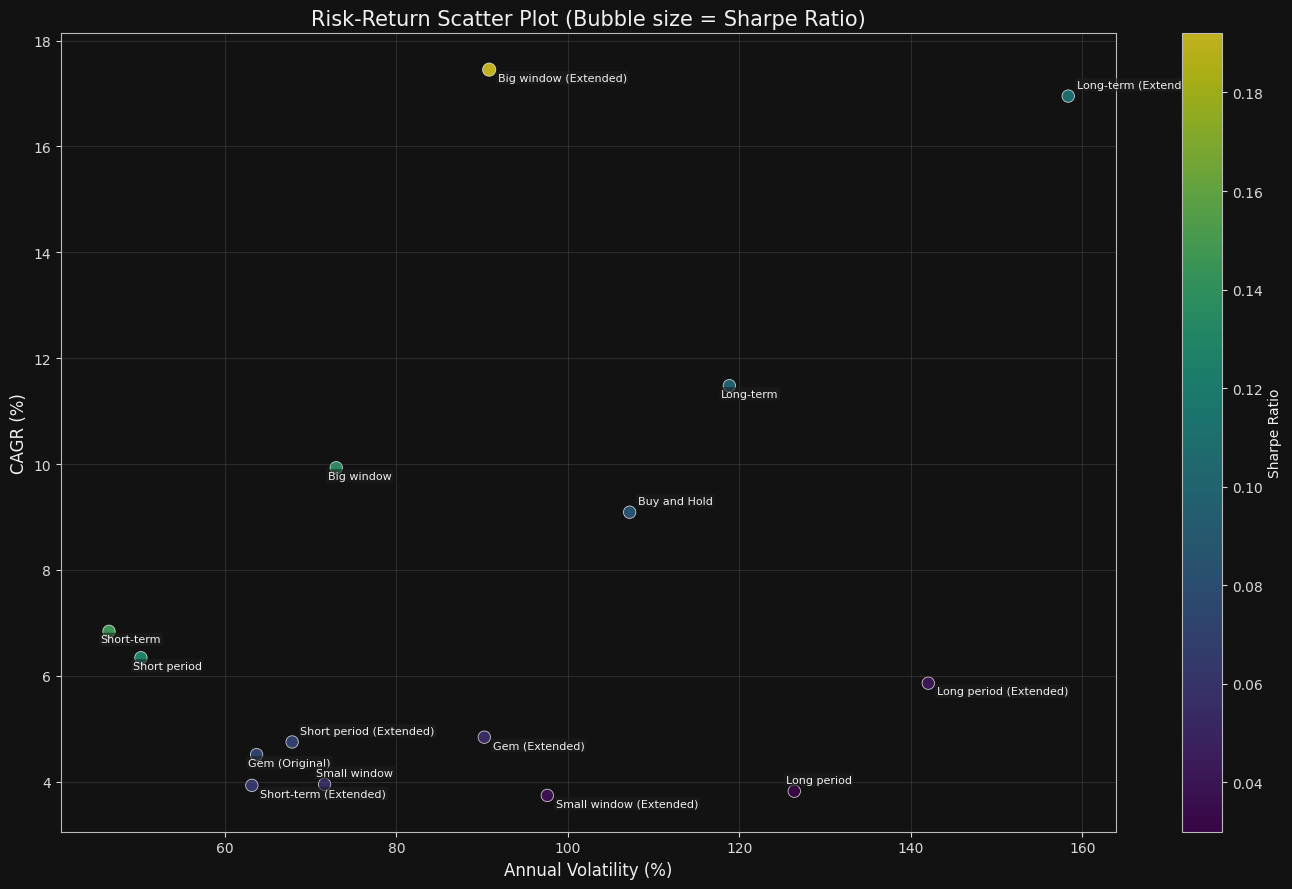

In [38]:
portfolios = {
    "Buy and Hold": {"values": buy_and_hold_values, "days": buy_and_hold_days},
    "Gem (Original)": {"values": gem_original_values, "days": gem_original_days},
    "Gem (Extended)": {
        "values": all_gem_original_values,
        "days": all_gem_original_days,
    },
    "Long period": {"values": gem_values_long_period, "days": gem_days_long_period},
    "Long period (Extended)": {
        "values": all_gem_values_long_period,
        "days": all_gem_days_long_period,
    },
    "Short period": {"values": gem_values_short_period, "days": gem_days_short_period},
    "Short period (Extended)": {
        "values": all_gem_values_short_period,
        "days": all_gem_days_short_period,
    },
    "Big window": {"values": gem_values_bigger_window, "days": gem_days_bigger_window},
    "Big window (Extended)": {
        "values": all_gem_values_bigger_window,
        "days": all_gem_days_bigger_window,
    },
    "Small window": {
        "values": gem_values_smaller_window,
        "days": gem_days_smaller_window,
    },
    "Small window (Extended)": {
        "values": all_gem_values_smaller_window,
        "days": all_gem_days_smaller_window,
    },
    "Long-term": {"values": gem_values_long_term, "days": gem_days_long_term},
    "Long-term (Extended)": {
        "values": all_gem_values_long_term,
        "days": all_gem_days_long_term,
    },
    "Short-term": {"values": gem_values_short_term, "days": gem_days_short_term},
    "Short-term (Extended)": {
        "values": all_gem_values_short_term,
        "days": all_gem_days_short_term,
    },
}

results = {}

for key, value in portfolios.items():
    stats = calculate_portfolio_statistics(value["values"], value["days"])
    results[key] = stats

# Transpose so portfolios are in columns
df_results = pd.DataFrame(results)
df_results = df_results.round(3)

# Display styled table
from IPython.display import display


def format_number(x, decimals=2, percent=False):
    """Format number without trailing zeros."""
    fmt = f"{x:.{decimals}f}"
    result = fmt.rstrip("0").rstrip(".")
    if percent:
        result += "%"
    return result


display(df_results.style.set_caption("Portfolio Performance Comparison"))

# Bar chart for key metrics - horizontal bars for readability
import matplotlib.pyplot as plt

key_metrics = ["cagr [%]", "sharpe_ratio", "max_drawdown [%]", "win_rate"]
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Key Performance Metrics Comparison", fontsize=18)

for i, metric in enumerate(key_metrics):
    ax = axes[i // 2, i % 2]
    values = df_results.loc[metric].astype(float).sort_values()
    labels = values.index

    if "drawdown" in metric:
        colors = ["#ff6b6b" if x < 0 else "#4cc9f0" for x in values.values]
    else:
        colors = ["#4cc9f0"] * len(values)

    bars = ax.barh(labels, values.values, color=colors, alpha=0.9)
    ax.set_title(metric.replace("[%]", "%").replace("_", " ").title(), fontsize=13)
    ax.set_xlabel(metric, fontsize=11)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    value_range = max(values.values) - min(values.values)
    x_pad = max(value_range * 0.01, 0.03)

    for bar, v in zip(bars, values.values):
        y_pos = bar.get_y() + bar.get_height() / 2
        if v >= 0:
            ax.text(v + x_pad, y_pos, f"{v:.2f}", va="center", fontsize=8)
        else:
            ax.text(v - x_pad, y_pos, f"{v:.2f}", va="center", ha="right", fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Scatter plot: Risk vs Return
fig, ax = plt.subplots(figsize=(14, 9))
cagr = df_results.loc["cagr [%]"].values.astype(float)
volatility = df_results.loc["annual_volatility [%]"].values.astype(float)
sharpe = df_results.loc["sharpe_ratio"].values.astype(float)
labels = df_results.columns

# Filter out NaN
valid = pd.notna(cagr) & pd.notna(volatility) & pd.notna(sharpe)
cagr = cagr[valid]
volatility = volatility[valid]
sharpe = sharpe[valid]
labels = labels[valid]

bubble_sizes = np.clip((sharpe - sharpe.min() + 0.2) * 250, 80, 900)
scatter = ax.scatter(
    volatility,
    cagr,
    s=bubble_sizes,
    alpha=0.75,
    c=sharpe,
    cmap="viridis",
    edgecolors="white",
    linewidth=0.6,
)
plt.colorbar(scatter, label="Sharpe Ratio")

ax.set_xlabel("Annual Volatility (%)", fontsize=12)
ax.set_ylabel("CAGR (%)", fontsize=12)
ax.set_title("Risk-Return Scatter Plot (Bubble size = Sharpe Ratio)", fontsize=15)

for i, txt in enumerate(labels):
    offset_x = 6 if i % 2 == 0 else -6
    offset_y = 6 if i % 3 == 0 else -8
    ax.annotate(
        txt,
        (volatility[i], cagr[i]),
        xytext=(offset_x, offset_y),
        textcoords="offset points",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.15", facecolor="#1e1e1e", alpha=0.6, edgecolor="none"
        ),
    )

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()